In [131]:
from confusion_matrix import TokenConfusionBenchmark, plot_token_confusion
import torch
import sys
from PIL import Image

from omegaconf import OmegaConf
from torchvision import transforms

src_path = '/mnt/DATA2/dorin/Image-Transform-Predict/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from dataset import ImageTransformer
from dataset import TransformTokenizer
from model import ImageTransformPredictor
from model import SiamNet

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [132]:
preprocess_effnet = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model_effnet = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_effnet.load_state_dict(checkpoint['model_state_dict'])
model_effnet.to('cuda')
model_effnet.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


In [133]:
preprocess_vit = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model_vit = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_vit.load_state_dict(checkpoint['model_state_dict'])
model_vit.to('cuda')
model_vit.eval()
print('ready')

ready


In [134]:
model = SiamNet()

preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

# checkpoint_path = "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/siamnet_pretrain/checkpoint_epoch_12.pth"
checkpoint_path = "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/siamnet_tune/checkpoint_epoch_1.pth"

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cuda')
model.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


In [135]:
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def human(n):
    return f"{n/1e9:.2f}B" if n >= 1e9 else f"{n/1e6:.2f}M"

models = {"Ours-ViT": model_vit, "Ours-EffNet": model_effnet, "SiamNet": model}
for name, m in models.items():
    total, trainable = count_parameters(m)
    print(f"{name:12s} total={human(total):>8s} ({total:,})  trainable={human(trainable)}")

Ours-ViT     total=  98.80M (98,797,824)  trainable=98.80M
Ours-EffNet  total=  24.87M (24,873,512)  trainable=24.87M
SiamNet      total=  13.06M (13,058,601)  trainable=13.06M


In [119]:
# device = torch.device("cuda")
# output_path = "metrics/metrics_v2/token_confusion.json"
# tokenizer = TransformTokenizer()
# transformer = ImageTransformer()
# data_path = "/mnt/DATA2/dorin/Image-Transform-Predict/data"

# models = {
#     "Ours-ViT-sft",
#     "Ours-ViT-pre", 
#     "Ours-EffNet-sft",
#     "Ours-EffNet-pre",
# }

# bench = TokenConfusionBenchmark(
#     model=model_effnet,
#     dataset_root=data_path,
#     tokenizer=tokenizer,
#     preprocess=preprocess_effnet,
#     device=device,
#     n_samples=5000,
#     exclude_domains=("quickdraw",),
# )
# bench.run("Ours-EffNet-pre", output_path)

In [118]:
# device = torch.device("cuda")
# output_path = "metrics/metrics_v2/token_confusion.json"
# tokenizer = TransformTokenizer()
# transformer = ImageTransformer()
# data_path = "/mnt/DATA2/dorin/Image-Transform-Predict/data"

# bench = TokenConfusionBenchmark(
#     model=model_vit,
#     dataset_root=data_path,
#     tokenizer=tokenizer,
#     preprocess=preprocess_vit,
#     device=device,
#     n_samples=5000,
#     exclude_domains=("quickdraw",),
# )
# bench.run("Ours-ViT-pre", output_path)

In [51]:
import json
with open("metrics/metrics_v2/token_confusion.json", encoding="utf-8") as f:
    data = json.load(f)

In [116]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 8,
    'grid.alpha': 0.3,
    'figure.dpi': 300,
    'font.weight': 'normal',
})

In [123]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_confusion_grid_journal(
    json_path,
    layout=(("Ours-EffNet-pre", "Ours-EffNet-sft"),
            ("Ours-ViT-pre",    "Ours-ViT-sft")),
    decimals=1, cmap="Blues", figsize=(15, 12), save_path=None,
):
    alld = json.loads(Path(json_path).read_text(encoding="utf-8"))
    nr, nc = len(layout), len(layout[0])
    fig, axes = plt.subplots(nr, nc, figsize=figsize, constrained_layout=True)
    letters = "abcdefgh"
    im, k = None, 0
    for i in range(nr):
        for j in range(nc):
            ax, name = axes[i][j], layout[i][j]
            res = alld[name]["results"]
            rL, cL, counts = res["row_labels"], res["col_labels"], res["counts"]
            M = np.array([[counts.get(r, {}).get(c, 0) for c in cL] for r in rL], float)
            s = M.sum(1, keepdims=True); s[s == 0] = 1.0
            shown = M / s * 100.0
            im = ax.imshow(shown, aspect="auto", cmap=cmap, vmin=0, vmax=100)
            ax.set_xticks(np.arange(-.5, len(cL), 1), minor=True)
            ax.set_yticks(np.arange(-.5, len(rL), 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.0)
            ax.tick_params(which="minor", length=0)
            ax.set_xticks(range(len(cL))); ax.set_yticks(range(len(rL)))
            if i == nr - 1:
                ax.set_xticklabels(cL, rotation=45, ha="right", fontsize=8)
                ax.set_xlabel("Predicted", fontsize=11)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_yticklabels(rL, fontsize=8)
                ax.set_ylabel("True", fontsize=11)
            else:
                ax.set_yticklabels([])
            ax.set_title(f"({letters[k]}) {name}", fontsize=12, loc="left", fontweight="bold")
            for sp in ax.spines.values(): sp.set_visible(False)
            for r in range(len(rL)):
                for c in range(len(cL)):
                    v = shown[r, c]
                    if v > 0:
                        ax.text(c, r, f"{v:.{decimals}f}", ha="center", va="center",
                                fontsize=6, color="white" if v > 60 else "#222222")
            k += 1
    cbar = fig.colorbar(im, ax=axes, fraction=0.030, pad=0.02, shrink=0.85)
    cbar.set_label("Row-normalized %", fontsize=11)
    cbar.outline.set_visible(False)
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig, axes

(<Figure size 5400x4200 with 5 Axes>,
 array([[<Axes: title={'center': 'Ours-EffNet-pre'}, ylabel='True'>,
         <Axes: title={'center': 'Ours-EffNet-sft'}>],
        [<Axes: title={'center': 'Ours-ViT-pre'}, xlabel='Predicted', ylabel='True'>,
         <Axes: title={'center': 'Ours-ViT-sft'}, xlabel='Predicted'>]],
       dtype=object))

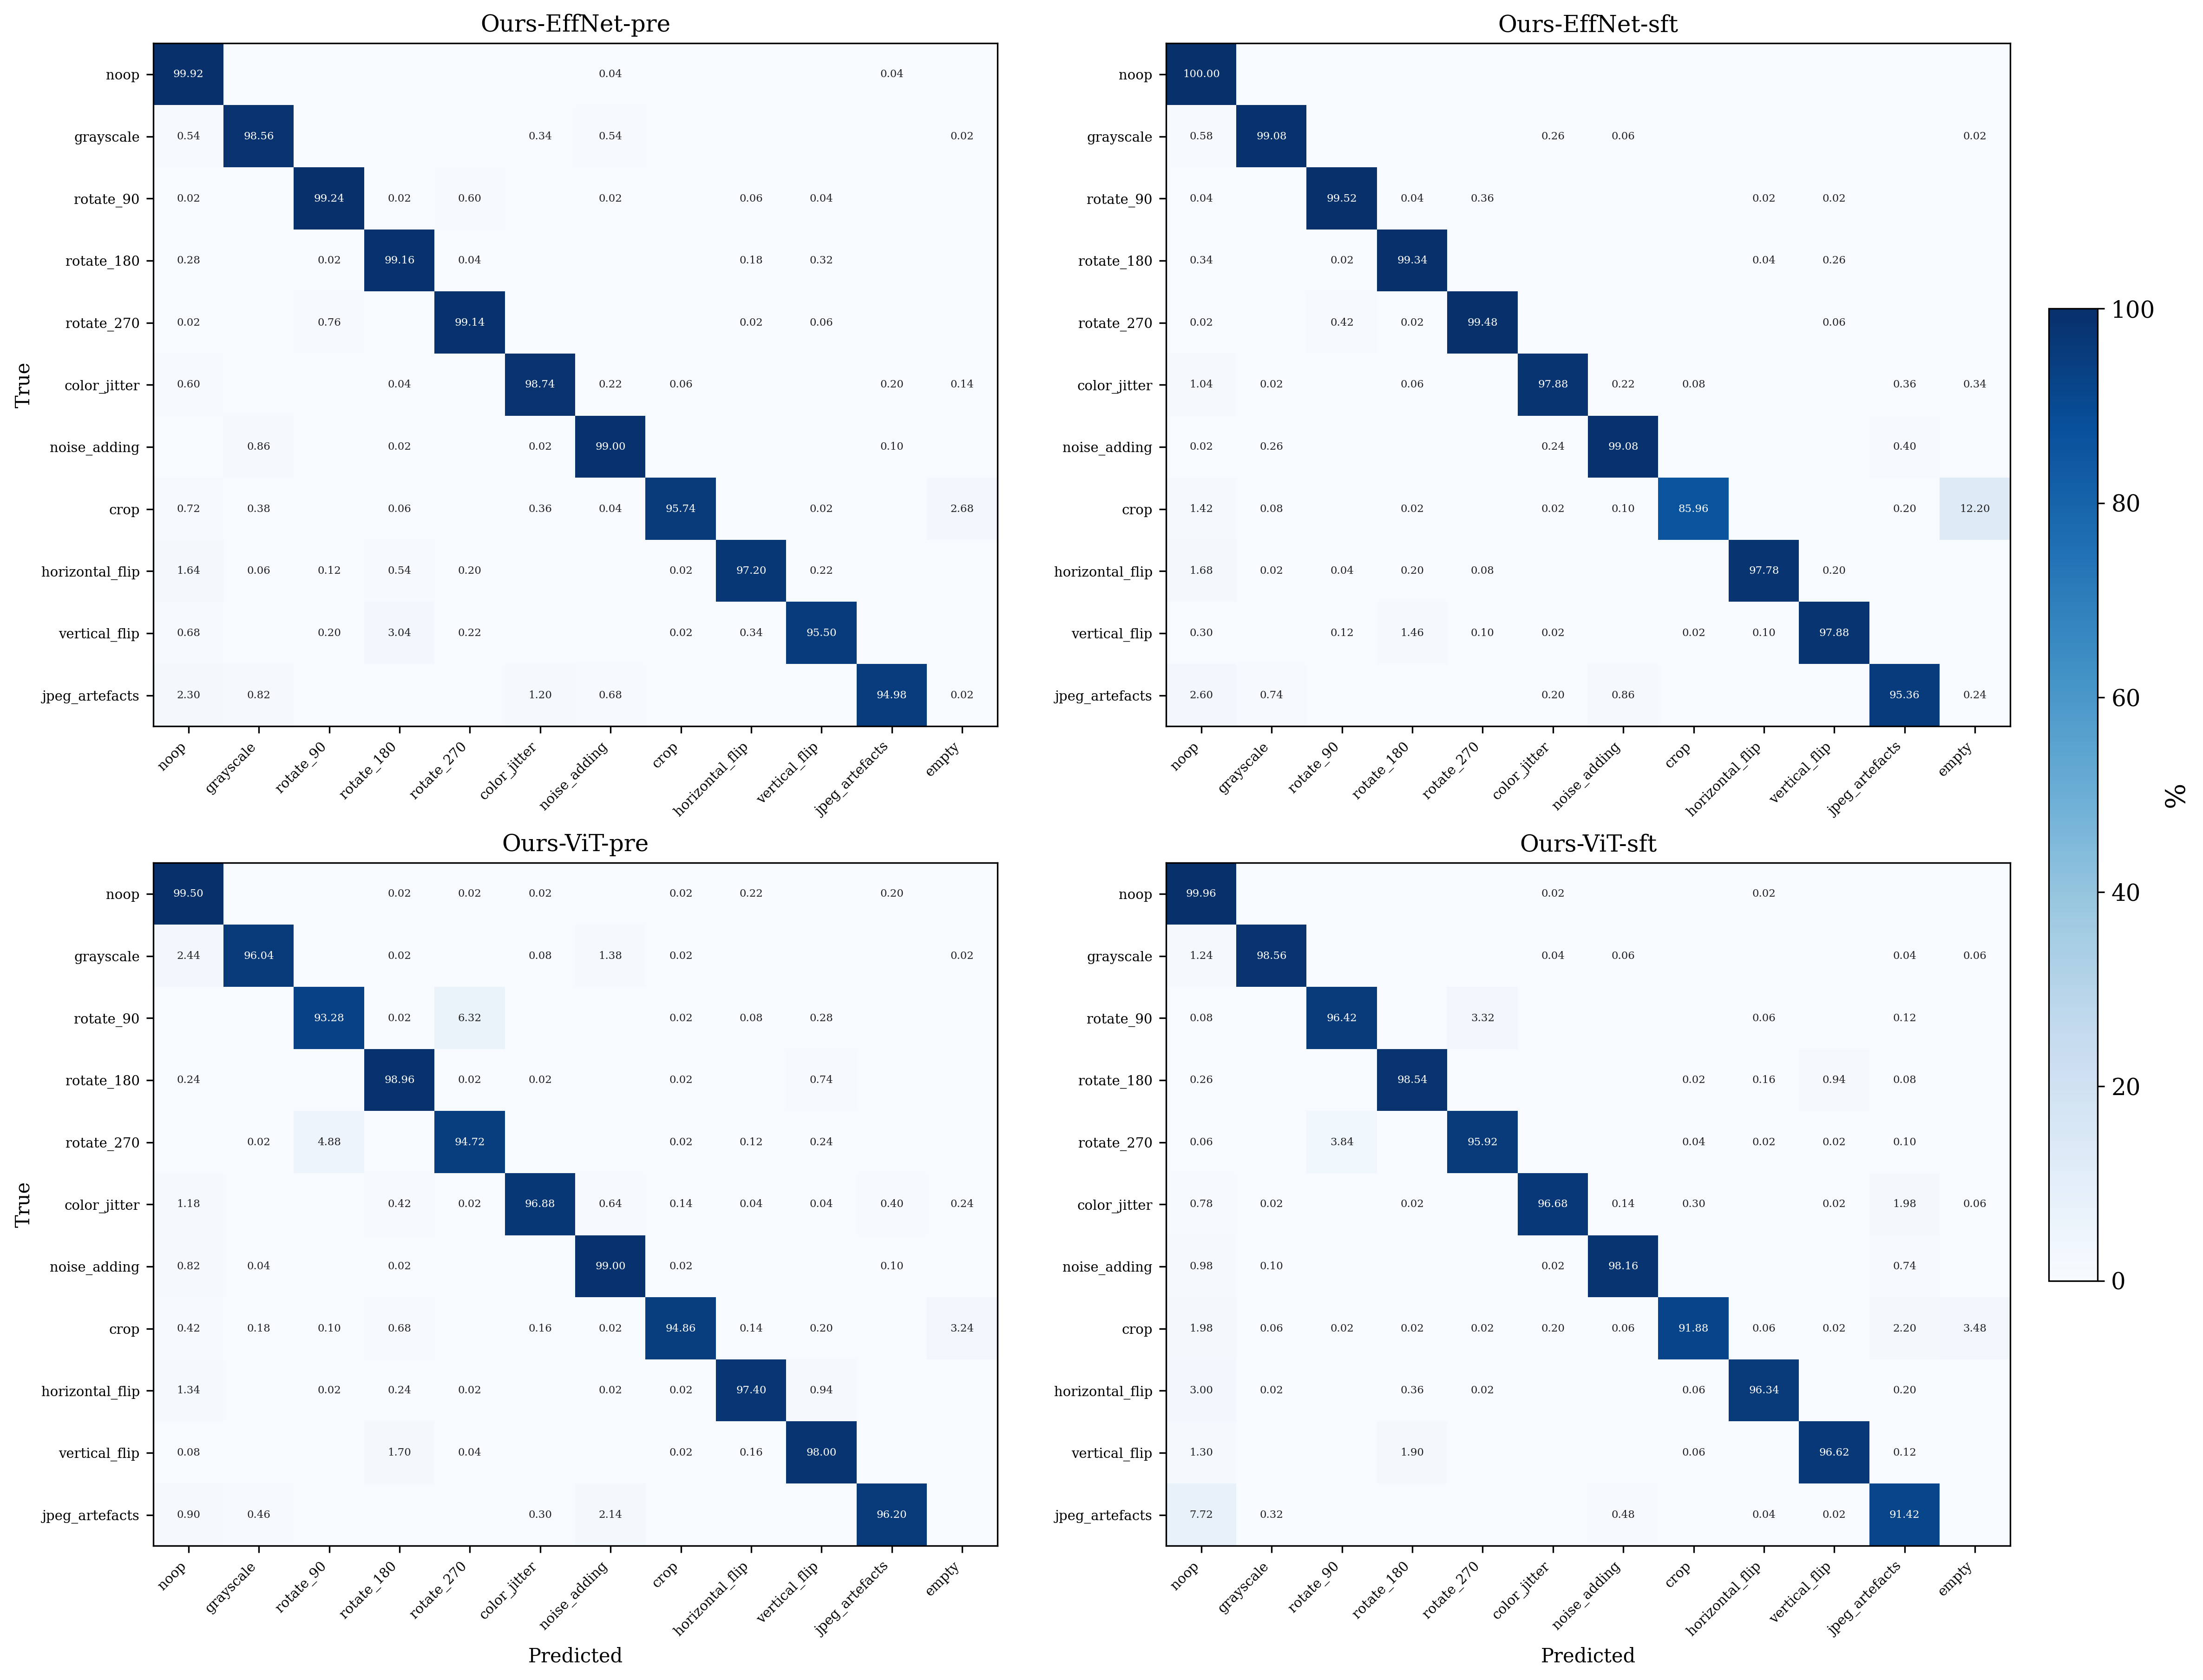

In [126]:
plot_token_confusion_grid("metrics/metrics_v2/token_confusion.json", decimals=2,
                          save_path="metrics/metrics_v2/confusion_grid.pdf")